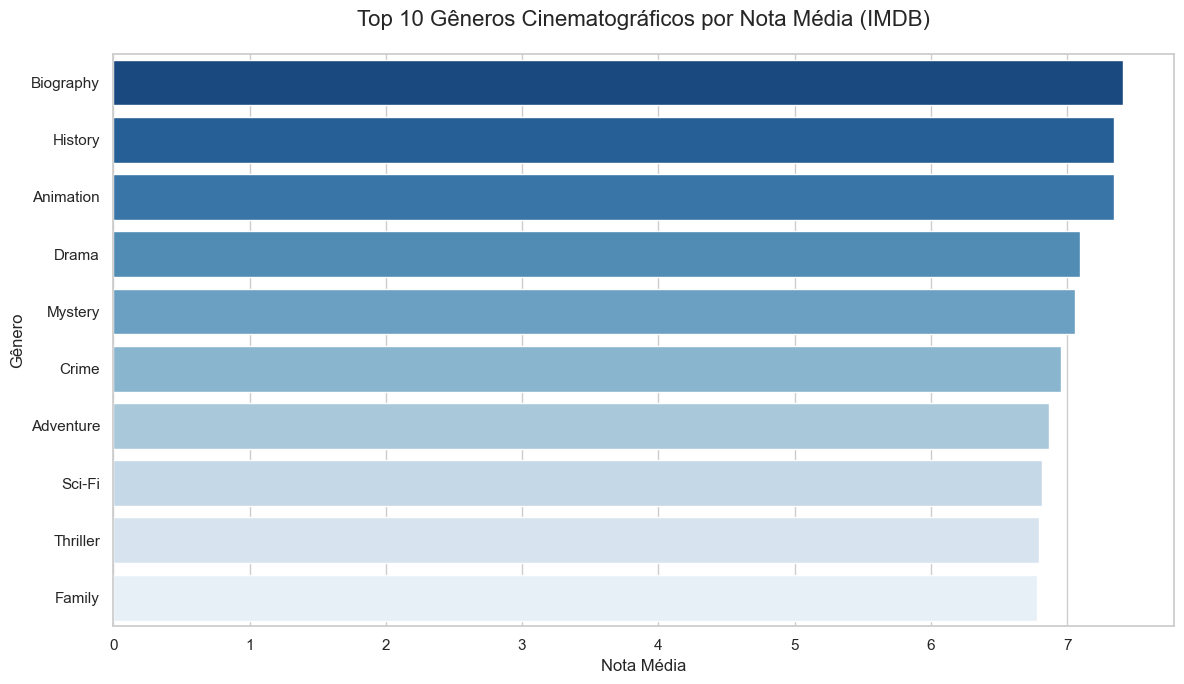

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Conexão com banco
conn = mysql.connector.connect(
  host='35.199.115.174',
  user='looqbox-challenge',
  password='looq-challenge',
  database='looqbox-challenge'
)

# Query
query = """
SELECT
  genre,
  rating,
  revenuemillions,
  year
FROM IMDB_movies
WHERE revenuemillions IS NOT NULL
"""

# Carregando dados
df_imdb = pd.read_sql(query, conn)

# Encerrando conexão
conn.close()

# Separar múltiplos gêneros
df_imdb['genre'] = df_imdb['genre'].str.split(',')

# Explodir lista em múltiplas linhas
df_imdb = df_imdb.explode('genre')

# Remover espaços extras
df_imdb['genre'] = df_imdb['genre'].str.strip()

# Estatísticas por gênero
genre_stats = (
    df_imdb.groupby('genre')
    .agg(
        avg_rating=('rating', 'mean'),
        movie_count=('genre', 'count')
    )
)

# Filtrar gêneros relevantes
top_genres = (
    genre_stats[genre_stats['movie_count'] >= 20]
    .sort_values(by='avg_rating', ascending=False)
    .head(10)
    .reset_index()
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# Gráfico
sns.barplot(
    data=top_genres,
    x='avg_rating',
    y='genre',
    palette='Blues_r'
)

# Título
plt.title(
    'Top 10 Gêneros Cinematográficos por Nota Média (IMDB)',
    fontsize=16,
    pad=20
)

# Labels
plt.xlabel('Nota Média', fontsize=12)
plt.ylabel('Gênero', fontsize=12)

# Ajuste layout
plt.tight_layout()

# Salvar imagem
plt.savefig('top_generos_imdb.png', dpi=300)

# Mostrar gráfico
plt.show()